# Módulo 3: Big Data y la Analítica de Datos para la Toma de Decisiones
## Unidad 1: Preparación y Arquitectura de Datos
### Notebook Formativo 3 — Análisis Exploratorio de Datos (EDA) y calidad industrial

**Escuchando el pulso de los activos antes de modelar**  
Diplomado en Gestión Industrial y Analítica de Datos — FCyT UMSS

---

## Propósito y resultados de aprendizaje

Este cuaderno guía una auditoría exploratoria de telemetría industrial. Al finalizar, podrá:

1. calcular e interpretar estadísticas descriptivas con Pandas;
2. comparar media, mediana y percentiles ante códigos de error y distribuciones asimétricas;
3. construir histogramas, boxplots y diagramas de dispersión con títulos, unidades y una intención analítica explícita;
4. aplicar reglas de dominio y la regla IQR para **marcar candidatos a revisión**, sin borrar registros de forma automática;
5. conservar el dato bruto y documentar una salida trazable para el Proyecto Integrador.

**Evidencia formativa:** notebook ejecutado, dos interpretaciones técnicas, reporte de calidad y puente de aplicación al proyecto.

> **Aviso didáctico:** todos los datos de este cuaderno son sintéticos. Los límites y códigos usados son supuestos del caso; no deben trasladarse a una planta real sin validación de Ingeniería de Procesos, Instrumentación y Seguridad.


## Ruta de trabajo

| Etapa | Pregunta de ingeniería | Producto |
|---|---|---|
| 1. Inspección | ¿Qué estructura y calidad aparente tiene el dataset? | Perfil inicial |
| 2. Descripción | ¿Cómo se distribuyen las variables y por activo? | Estadísticas robustas |
| 3. Visualización | ¿Qué patrones y anomalías requieren atención? | Gráficos interpretables |
| 4. Veracidad | ¿Es código centinela, falta de dato o candidato estadístico? | Banderas de calidad |
| 5. Trazabilidad | ¿Podemos reproducir y explicar cada decisión? | Cuarentena y pruebas |
| 6. Proyecto | ¿Cómo se adapta el método al problema del grupo? | Ficha exploratoria |

**Regla de oro:** explorar antes de modelar; marcar antes de eliminar; justificar antes de transformar.


## 0. Preparación del entorno

Ejecute las celdas en orden. Si usa Google Colab, el entorno es temporal: conserve el notebook en Drive o descárguelo al finalizar.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    # Fallback for a plain Python runtime; Colab/Jupyter uses rich display.
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

SEMILLA = 42
CODIGO_CENTINELA = -999.0
print("Entorno preparado. Semilla reproducible:", SEMILLA)


Entorno preparado. Semilla reproducible: 42


## 0.1 Ejemplo de aula — lote didáctico de temperatura

Antes de construir el dataset completo de la sección 1, reproduzca aquí el ejemplo de pizarra comentado al abrir la sesión: un lote pequeño de diez lecturas, usado solo para mostrar cómo un promedio se rompe cuando conviven un código centinela y lecturas físicamente extremas.

**Este bloque es independiente del dataset `df_sensor` que sigue.** No lo reutilice como fuente de las secciones 2 en adelante — ahí trabajamos con las 180 lecturas de los tres reactores.

In [3]:
# Lote didáctico de 10 lecturas (ejemplo de pizarra, independiente de df_sensor)
lote_didactico = pd.Series(
    [-999, -999, 1005, 1550, 1570, 1580, 1600, 1620, 1780, 1795],
    name="temperatura_c_lote_didactico",
)

perfil_lote = lote_didactico.describe().round(1)
print("=== Perfil del lote didáctico (10 lecturas) ===")
display(perfil_lote)

n_centinela = lote_didactico.eq(CODIGO_CENTINELA).sum()
n_fuera_de_rango = lote_didactico.gt(1750).sum()  # umbral ilustrativo para este ejemplo puntual
print(f"\nLecturas con código centinela (-999): {n_centinela}")
print(f"Lecturas fuera de rango plausible (> 1750 °C): {n_fuera_de_rango}")
print(f"Total de lecturas a investigar: {n_centinela + n_fuera_de_rango}")

=== Perfil del lote didáctico (10 lecturas) ===


count      10.00
mean    1,050.20
std     1,101.30
min      -999.00
25%     1,141.20
50%     1,575.00
75%     1,615.00
max     1,795.00
Name: temperatura_c_lote_didactico, dtype: float64


Lecturas con código centinela (-999): 2
Lecturas fuera de rango plausible (> 1750 °C): 2
Total de lecturas a investigar: 4


Compare esta salida con la diapositiva de Estadística Descriptiva de hoy: la media de 1050,2 °C, la mediana de 1575 °C y las cuatro lecturas a investigar (dos centinelas más dos fuera de rango) deberían coincidir exactamente. La desviación estándar puede variar unos pocos grados frente a la diapositiva — este lote nunca fue una base de datos real, es un ejemplo reconstruido para la clase, y ese pequeño margen es esperable.

A partir de aquí trabajamos con un dataset sintético nuevo — no es continuación de `produccion_industrial.csv` de la Sesión 2. Aquel archivo era un lote ilustrativo de cinco filas, insuficiente para que un histograma, un boxplot o un cálculo de IQR tengan sentido estadístico; por eso este notebook genera un lote más amplio (180 lecturas, tres reactores) manteniendo el mismo principio de auditoría.

## 1. Dataset sintético y preservación del origen

Simularemos 180 lecturas de tres reactores. El lote incluye:

- operación estable con diferencias pequeñas entre activos;
- tres registros con el **código centinela documentado** `-999 °C`;
- dos temperaturas físicamente posibles, pero inusuales respecto del régimen típico;
- dos valores faltantes en producción (ya visibles en la Sección 2 con `df.info()`; la auditoría de veracidad de la Sección 5 se enfoca en la temperatura — audítelos usted mismo si elige `produccion_t` en el mini-reto del Bloque 5);
- una bandera de falla (`normal`/`falla`) cuya probabilidad crece con la temperatura pero nunca es determinista — el mismo ejemplo que grafica el Bloque 3 al hablar de correlación y causalidad.

El código `-999` representa una lectura inválida del instrumento en este caso didáctico. Su causa real no puede inferirse solo con el dato: requiere revisar manuales, logs y condiciones de campo.


In [4]:
rng = np.random.default_rng(SEMILLA)
n_registros = 180

timestamp = pd.date_range("2026-09-10 07:00", periods=n_registros, freq="5min")
tipo_maquina = np.resize(np.array(["Reactor_A", "Reactor_B", "Reactor_C"]), n_registros)
temperatura_base = {"Reactor_A": 1575.0, "Reactor_B": 1585.0, "Reactor_C": 1592.0}
centro_termico = np.array([temperatura_base[m] for m in tipo_maquina])

temperatura_c = centro_termico + rng.normal(0, 12, n_registros)
presion_bar = 5.8 + 0.002 * (temperatura_c - 1580) + rng.normal(0, 0.12, n_registros)
vibracion_mm_s = np.clip(rng.normal(0.10, 0.025, n_registros), 0.03, None)
produccion_t = (
    82
    + 0.035 * (temperatura_c - 1570)
    - 18 * np.abs(presion_bar - 5.8)
    + rng.normal(0, 3.5, n_registros)
)

# Bandera de falla sintética: probabilidad creciente con la temperatura,
# pero nunca determinista (evita una separación perfecta) — acompaña el
# ejemplo de dispersión y causalidad del Bloque 3 (hue="falla").
centro_falla = np.quantile(temperatura_c, 0.80)
prob_falla = 1 / (1 + np.exp(-0.06 * (temperatura_c - centro_falla)))
prob_falla = np.clip(prob_falla, 0.03, 0.65)
falla = np.where(rng.random(n_registros) < prob_falla, "falla", "normal")

df_sensor = pd.DataFrame({
    "id_registro": [f"TEL-{i:04d}" for i in range(1, n_registros + 1)],
    "timestamp": timestamp,
    "tipo_maquina": tipo_maquina,
    "temperatura_c": temperatura_c,
    "presion_bar": presion_bar,
    "vibracion_mm_s": vibracion_mm_s,
    "produccion_t": produccion_t,
    "falla": falla,
})

# Anomalías controladas para el laboratorio.
indices_centinela = [17, 83, 142]
indices_atipicos = [48, 109]
indices_faltantes = [31, 125]

df_sensor.loc[indices_centinela, "temperatura_c"] = CODIGO_CENTINELA
df_sensor.loc[indices_atipicos, "temperatura_c"] = [1450.0, 1715.0]
df_sensor.loc[indices_atipicos, "produccion_t"] = [61.0, 58.0]
df_sensor.loc[indices_faltantes, "produccion_t"] = np.nan

# Instantánea inmutable de referencia para comprobar que el raw no se altere.
df_raw_snapshot = df_sensor.copy(deep=True)

print(f"Dataset sintético creado: {df_sensor.shape[0]} filas × {df_sensor.shape[1]} columnas")
print(f"Registros marcados como 'falla': {(df_sensor['falla'] == 'falla').sum()} de {n_registros}")
display(df_sensor.head())


Dataset sintético creado: 180 filas × 8 columnas
Registros marcados como 'falla': 64 de 180


,id_registro,timestamp,tipo_maquina,temperatura_c,presion_bar,vibracion_mm_s,produccion_t,falla
0,TEL-0001,2026-09-10 07:00:00,Reactor_A,"1,578.66",5.95,0.10,73.63,falla
1,TEL-0002,2026-09-10 07:05:00,Reactor_B,"1,572.52",5.81,0.11,78.99,normal
2,TEL-0003,2026-09-10 07:10:00,Reactor_C,"1,601.01",5.79,0.12,83.82,falla
3,TEL-0004,2026-09-10 07:15:00,Reactor_A,"1,586.29",5.95,0.07,79.33,normal
4,TEL-0005,2026-09-10 07:20:00,Reactor_B,"1,561.59",5.81,0.10,80.56,normal


### Diccionario mínimo del caso

| Variable | Tipo esperado | Unidad / dominio | Uso |
|---|---|---|---|
| `id_registro` | texto | identificador único | Linaje |
| `timestamp` | fecha-hora | cada 5 minutos | Orden temporal |
| `tipo_maquina` | categoría | Reactor_A/B/C | Segmentación |
| `temperatura_c` | numérico | °C; `-999` es centinela | Variable crítica |
| `presion_bar` | numérico | bar | Contexto de proceso |
| `vibracion_mm_s` | numérico | mm/s | Condición del activo |
| `produccion_t` | numérico | toneladas | Resultado operativo |
| `falla` | categoría | `normal` / `falla` | Ejemplo de dispersión y causalidad (Bloque 3) |


## 2. Inspección estructural antes del cálculo

`head()` muestra ejemplos; `shape` informa dimensiones; `info()` resume tipos y valores no nulos. Ninguno reemplaza la interpretación del proceso.


In [5]:
print("Dimensiones:", df_sensor.shape)
print("\nDuplicados por id_registro:", df_sensor["id_registro"].duplicated().sum())
print("\nValores faltantes por variable:")
display(df_sensor.isna().sum().rename("faltantes").to_frame())
print("\nEstructura del DataFrame:")
df_sensor.info()


Dimensiones: (180, 8)

Duplicados por id_registro: 0

Valores faltantes por variable:


,faltantes
id_registro,0
timestamp,0
tipo_maquina,0
temperatura_c,0
presion_bar,0
vibracion_mm_s,0
produccion_t,2
falla,0



Estructura del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_registro     180 non-null    str           
 1   timestamp       180 non-null    datetime64[us]
 2   tipo_maquina    180 non-null    str           
 3   temperatura_c   180 non-null    float64       
 4   presion_bar     180 non-null    float64       
 5   vibracion_mm_s  180 non-null    float64       
 6   produccion_t    178 non-null    float64       
 7   falla           180 non-null    str           
dtypes: datetime64[us](1), float64(4), str(3)
memory usage: 11.4 KB


## 3. Estadística descriptiva: el sesgo del promedio bruto

Compararemos la temperatura tal como llegó con una vista que solo sustituye el código centinela por `NaN`. Esta segunda vista no borra filas ni modifica `df_sensor`; evita que un código de estado participe en cálculos físicos.


In [6]:
es_centinela_documentado = df_sensor["temperatura_c"].eq(CODIGO_CENTINELA)
temperatura_sin_centinela = df_sensor["temperatura_c"].mask(es_centinela_documentado)

comparacion_temperatura = pd.DataFrame({
    "Bruta (incluye código)": df_sensor["temperatura_c"].describe(),
    "Analítica (código en NaN)": temperatura_sin_centinela.describe(),
}).round(2)

display(comparacion_temperatura)
print(f"Media bruta: {df_sensor['temperatura_c'].mean():.2f} °C")
print(f"Mediana bruta: {df_sensor['temperatura_c'].median():.2f} °C")
print(f"Media sin centinela: {temperatura_sin_centinela.mean():.2f} °C")


,Bruta (incluye código),Analítica (código en NaN)
count,180.00,177.00
mean,"1,540.50","1,583.55"
std,332.06,18.78
min,-999.00,"1,450.00"
25%,"1,573.94","1,574.61"
50%,"1,582.71","1,582.98"
75%,"1,593.89","1,593.90"
max,"1,715.00","1,715.00"


Media bruta: 1540.50 °C
Mediana bruta: 1582.71 °C
Media sin centinela: 1583.55 °C


### Pausa de análisis 1 — interpretación individual

1. ¿Cuánto cambia la media cuando el código centinela deja de tratarse como temperatura?
2. ¿Por qué la mediana es más estable en este caso?
3. ¿Qué decisión incorrecta podría tomar un supervisor si utiliza solo la media bruta?

> **Respuesta del participante:** escriba aquí una interpretación breve que incluya unidad, causa probable y riesgo de negocio.
1. ¿Cuánto cambia la media?
La media pasa de 1540,50 °C a 1583,55 °C, aumentando 43,04 °C cuando -999 deja de tratarse como una temperatura. El centinela reducía artificialmente el promedio.
2. ¿Por qué la mediana es más estable?
La mediana solo cambia de 1582,71 °C a 1582,98 °C, una diferencia de 0,27 °C. Es más estable porque depende de la posición central de los datos y no de la magnitud extrema de -999.
3. ¿Qué decisión incorrecta podría tomarse?
Un supervisor podría concluir que el proceso trabaja a una temperatura demasiado baja y modificar innecesariamente la operación. Esto podría aumentar el consumo energético, alterar el producto o provocar una intervención equivocada.


### Segmentación por activo

El resumen global puede ocultar diferencias entre reactores. Para comparar activos de forma justa, excluimos únicamente el código centinela documentado y mantenemos los valores inusuales para revisión.


In [7]:
base_sin_centinela = df_sensor.loc[~es_centinela_documentado].copy()

resumen_reactores = (
    base_sin_centinela
    .groupby("tipo_maquina", observed=True)["temperatura_c"]
    .agg(
        registros="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max",
    )
    .round(2)
)
display(resumen_reactores)


,registros,media,mediana,desviacion,minimo,maximo
tipo_maquina,,,,,,
Reactor_A,60,"1,572.53","1,573.47",19.25,"1,450.00","1,600.70"
Reactor_B,59,"1,586.48","1,583.58",19.97,"1,561.59","1,715.00"
Reactor_C,58,"1,591.96","1,593.93",9.57,"1,571.90","1,613.22"


## 4. Visualización descriptiva: elegir con intención

- **Histograma:** forma, concentración y asimetría de una variable.
- **Boxplot:** mediana, rango intercuartílico y candidatos estadísticos.
- **Dispersión:** asociación entre dos variables; **no demuestra causalidad**.

Primero mostraremos por qué el código centinela deforma la escala y luego analizaremos la temperatura sin confundir estado del sensor con magnitud física.


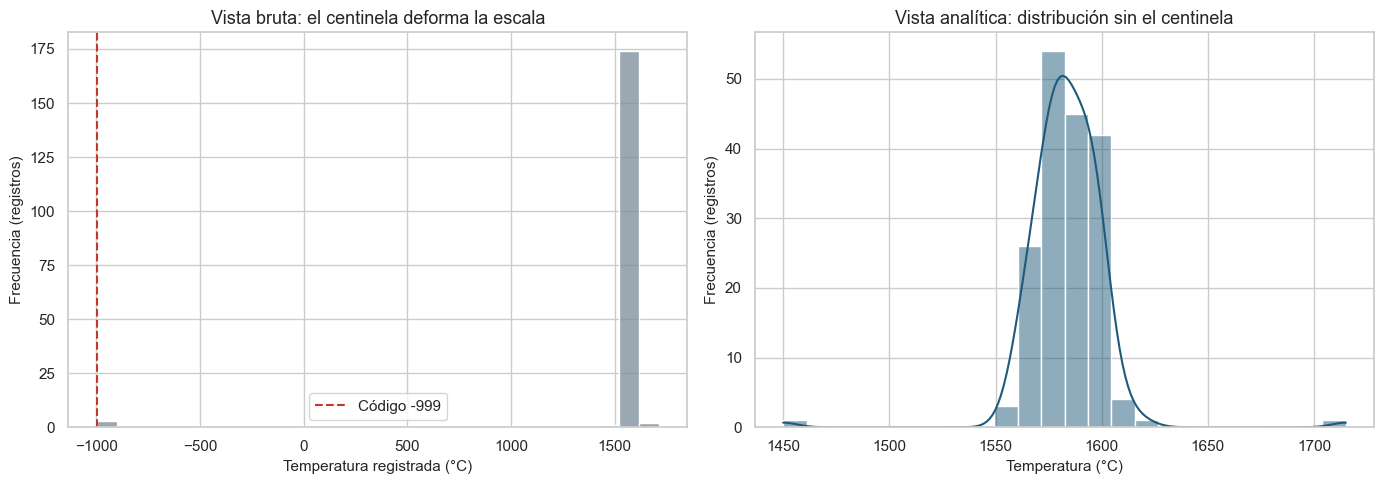

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_sensor["temperatura_c"], bins=28, ax=axes[0], color="#7A8A99")
axes[0].axvline(CODIGO_CENTINELA, color="#C0392B", linestyle="--", label="Código -999")
axes[0].set_title("Vista bruta: el centinela deforma la escala")
axes[0].set_xlabel("Temperatura registrada (°C)")
axes[0].set_ylabel("Frecuencia (registros)")
axes[0].legend()

sns.histplot(
    data=base_sin_centinela,
    x="temperatura_c",
    bins=24,
    kde=True,
    ax=axes[1],
    color="#1F5A7A",
)
axes[1].set_title("Vista analítica: distribución sin el centinela")
axes[1].set_xlabel("Temperatura (°C)")
axes[1].set_ylabel("Frecuencia (registros)")

plt.tight_layout()
plt.show()


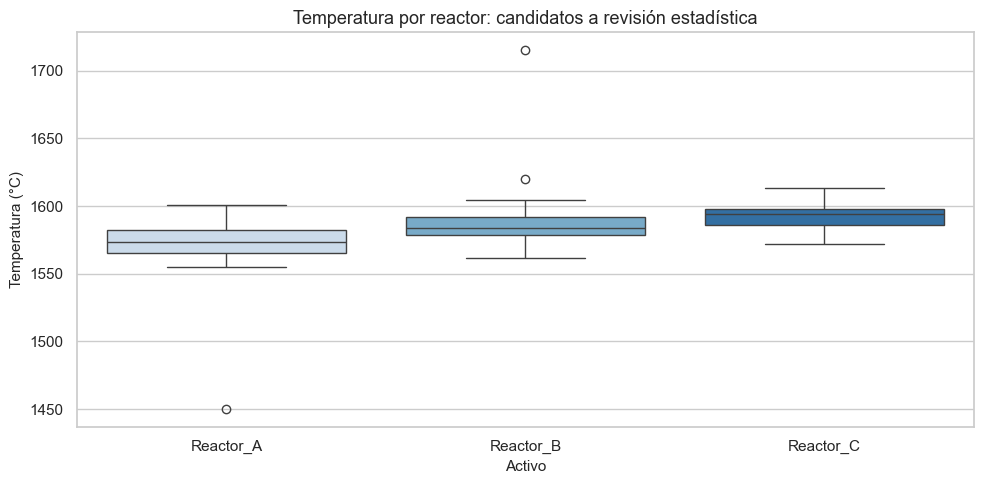

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=base_sin_centinela,
    x="tipo_maquina",
    y="temperatura_c",
    hue="tipo_maquina",
    palette="Blues",
    legend=False,
)
plt.title("Temperatura por reactor: candidatos a revisión estadística")
plt.xlabel("Activo")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


### Pausa de análisis 2 — lectura de gráficos

1. ¿Qué diferencia observa entre la vista bruta y la vista analítica del histograma?
2. ¿Qué puntos del boxplot requieren revisión y por qué todavía no deben eliminarse?
3. ¿Conviene calcular un único límite para toda la planta o límites por activo/régimen operativo? Justifique.

> **Respuesta del participante:** escriba aquí su interpretación. Evite afirmar causalidad si el gráfico solo muestra una asociación.
1. Diferencia entre histogramas
El histograma bruto queda deformado por -999, que extiende el eje y comprime las temperaturas reales. Al retirarlo del cálculo, se observa la concentración principal aproximadamente entre 1575 y 1595 °C, además de las lecturas inusuales.
2. Puntos que requieren revisión
Los principales candidatos son TEL-0049 con 1450 °C y TEL-0110 con 1715 °C. Al calcular el boxplot por reactor también aparece TEL-0140 con aproximadamente 1619,97 °C como candidato del Reactor B. No deben eliminarse porque podrían ser mediciones válidas de otro régimen, una condición transitoria o un error del instrumento.
3. ¿Un límite general o por activo?
Conviene calcular límites por reactor o régimen operativo porque sus temperaturas centrales son diferentes. Un límite global podría considerar anormal una lectura válida de un reactor o esconder una anomalía dentro de otro.


### Relación bivariada: temperatura y producción

La siguiente gráfica colorea los puntos por estado de falla — el mismo ejemplo que trabajó en el Bloque 3 de la sesión. Una asociación visual o un coeficiente de correlación no prueba que la temperatura cause el cambio de producción, ni que la temperatura cause la falla; pueden intervenir carga, materia prima, turno, presión u otras variables.


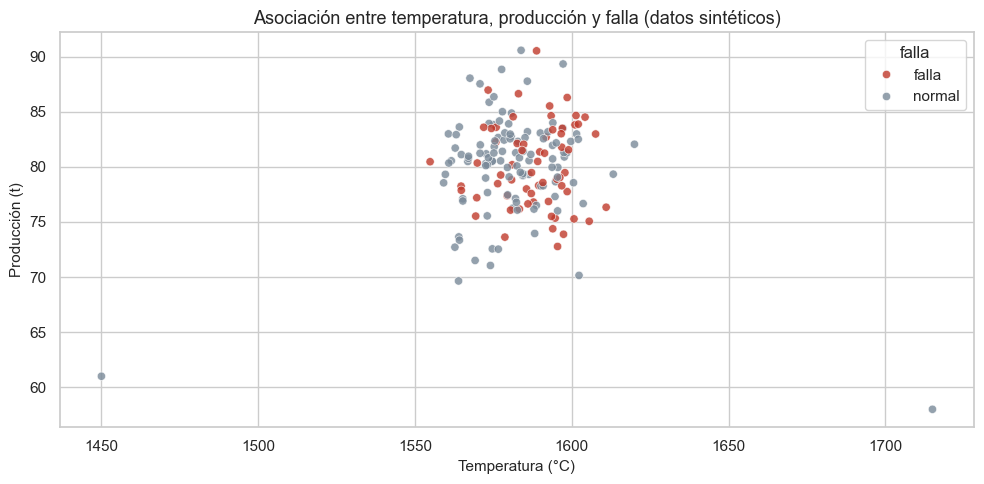

Correlación de Pearson (temperatura vs. producción): 0.001
Proporción de registros marcados como 'falla': 36.0%
Interpretación: los puntos de falla se concentran en temperaturas altas, pero la asociación no demuestra causalidad — igual que en el lienzo del Bloque 3.


In [10]:
base_bivariada = base_sin_centinela.dropna(subset=["temperatura_c", "produccion_t"])
correlacion = base_bivariada[["temperatura_c", "produccion_t"]].corr().iloc[0, 1]

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=base_bivariada,
    x="temperatura_c",
    y="produccion_t",
    hue="falla",
    palette={"normal": "#7A8A99", "falla": "#C0392B"},
    alpha=0.80,
)
plt.title("Asociación entre temperatura, producción y falla (datos sintéticos)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Producción (t)")
plt.tight_layout()
plt.show()

tasa_falla = (base_bivariada["falla"] == "falla").mean()
print(f"Correlación de Pearson (temperatura vs. producción): {correlacion:.3f}")
print(f"Proporción de registros marcados como 'falla': {tasa_falla:.1%}")
print("Interpretación: los puntos de falla se concentran en temperaturas altas, pero la asociación no demuestra causalidad — igual que en el lienzo del Bloque 3.")


## 5. Auditoría de veracidad: reglas de dominio + IQR

Separaremos tres situaciones:

1. **Faltante:** no existe una lectura disponible.
2. **Código centinela documentado:** el número representa un estado del instrumento, no una temperatura.
3. **Candidato IQR:** lectura fuera de los límites estadísticos del lote; requiere contexto y revisión, no eliminación automática.

> En producción, los límites deben definirse por activo, modo de operación, receta o turno cuando esos estratos tengan comportamientos distintos. Aquí usamos un límite global para practicar la mecánica de la regla.


In [11]:
df_trabajo = df_sensor.copy(deep=True)

df_trabajo["es_faltante_temp"] = df_trabajo["temperatura_c"].isna()
df_trabajo["es_centinela_temp"] = df_trabajo["temperatura_c"].eq(CODIGO_CENTINELA)
df_trabajo["temperatura_analitica_c"] = df_trabajo["temperatura_c"].mask(
    df_trabajo["es_centinela_temp"]
)

base_iqr = df_trabajo["temperatura_analitica_c"].dropna()
q1, q3 = base_iqr.quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_trabajo["es_candidato_iqr"] = (
    df_trabajo["temperatura_analitica_c"].notna()
    & ~df_trabajo["temperatura_analitica_c"].between(limite_inferior, limite_superior)
)

condiciones = [
    df_trabajo["es_faltante_temp"],
    df_trabajo["es_centinela_temp"],
    df_trabajo["es_candidato_iqr"],
]
estados = ["FALTANTE", "CODIGO_CENTINELA", "REVISAR_IQR"]
motivos = [
    "No existe lectura de temperatura",
    "Código de estado documentado; no es una magnitud física",
    "Fuera de los límites IQR del lote; requiere contexto operativo",
]

df_trabajo["estado_calidad_temp"] = np.select(condiciones, estados, default="VALIDO")
df_trabajo["motivo_calidad_temp"] = np.select(condiciones, motivos, default="Dentro de reglas actuales")

print(f"Q1: {q1:.2f} °C | Q3: {q3:.2f} °C | IQR: {iqr:.2f} °C")
print(f"Límite inferior IQR: {limite_inferior:.2f} °C")
print(f"Límite superior IQR: {limite_superior:.2f} °C")


Q1: 1574.61 °C | Q3: 1593.90 °C | IQR: 19.29 °C
Límite inferior IQR: 1545.67 °C
Límite superior IQR: 1622.84 °C


In [12]:
reporte_calidad = (
    df_trabajo["estado_calidad_temp"]
    .value_counts(dropna=False)
    .rename_axis("estado_calidad_temp")
    .reset_index(name="registros")
)
reporte_calidad["porcentaje"] = 100 * reporte_calidad["registros"] / len(df_trabajo)
display(reporte_calidad.round({"porcentaje": 2}))


,estado_calidad_temp,registros,porcentaje
0,VALIDO,175,97.22
1,CODIGO_CENTINELA,3,1.67
2,REVISAR_IQR,2,1.11


### Cuarentena auditable

La cuarentena es una **vista de revisión**, no un borrado. Conserva el identificador, la hora, el activo, el valor original y la razón de la bandera para que Operaciones, Mantenimiento o Instrumentación decidan el tratamiento.


In [13]:
columnas_revision = [
    "id_registro",
    "timestamp",
    "tipo_maquina",
    "temperatura_c",
    "estado_calidad_temp",
    "motivo_calidad_temp",
]

df_cuarentena = (
    df_trabajo.loc[df_trabajo["estado_calidad_temp"] != "VALIDO", columnas_revision]
    .sort_values(["estado_calidad_temp", "timestamp"])
    .reset_index(drop=True)
)

df_analitico = df_trabajo.loc[df_trabajo["estado_calidad_temp"] == "VALIDO"].copy()

print("Registros enviados a revisión:", len(df_cuarentena))
print("Registros habilitados para el análisis bajo las reglas actuales:", len(df_analitico))
display(df_cuarentena)


Registros enviados a revisión: 5
Registros habilitados para el análisis bajo las reglas actuales: 175


,id_registro,timestamp,tipo_maquina,temperatura_c,estado_calidad_temp,motivo_calidad_temp
0,TEL-0018,2026-09-10 08:25:00,Reactor_C,-999.00,CODIGO_CENTINELA,Código de estado documentado; no es una magnit...
1,TEL-0084,2026-09-10 13:55:00,Reactor_C,-999.00,CODIGO_CENTINELA,Código de estado documentado; no es una magnit...
2,TEL-0143,2026-09-10 18:50:00,Reactor_B,-999.00,CODIGO_CENTINELA,Código de estado documentado; no es una magnit...
3,TEL-0049,2026-09-10 11:00:00,Reactor_A,"1,450.00",REVISAR_IQR,Fuera de los límites IQR del lote; requiere co...
4,TEL-0110,2026-09-10 16:05:00,Reactor_B,"1,715.00",REVISAR_IQR,Fuera de los límites IQR del lote; requiere co...


## 6. Pruebas automáticas de integridad

Las pruebas deben detener la ejecución si una regla crítica se incumple. Por eso no ocultamos los errores con un `try/except` genérico.


In [14]:
pd.testing.assert_frame_equal(df_sensor, df_raw_snapshot)
assert len(df_sensor) == len(df_trabajo), "La auditoría cambió el número de filas."
assert df_trabajo["id_registro"].is_unique, "Existen identificadores duplicados."
assert df_trabajo["estado_calidad_temp"].notna().all(), "Hay estados de calidad nulos."
assert df_trabajo.loc[df_trabajo["es_centinela_temp"], "estado_calidad_temp"].eq("CODIGO_CENTINELA").all()
assert not df_analitico["temperatura_c"].eq(CODIGO_CENTINELA).any()
assert df_cuarentena["motivo_calidad_temp"].str.len().gt(0).all()

print("✓ Raw preservado")
print("✓ Linaje e identificadores consistentes")
print("✓ Centinelas separados de las magnitudes físicas")
print("✓ Cada registro en cuarentena conserva una justificación")


✓ Raw preservado
✓ Linaje e identificadores consistentes
✓ Centinelas separados de las magnitudes físicas
✓ Cada registro en cuarentena conserva una justificación


## 7. Puente al Proyecto Integrador

Adapte el patrón anterior a una variable crítica de su dataset autorizado. Antes de programar, complete este contrato de análisis:

| Elemento | Respuesta del grupo |
|---|---|
| Decisión industrial que se desea mejorar | ... |
| Variable crítica y unidad | ... |
| Activo, proceso o régimen operativo | ... |
| Códigos centinela documentados | ... |
| Valores faltantes y causa probable | ... |
| Regla estadística elegida | ... |
| Responsable de validar los candidatos | ... |
| Acción permitida: marcar, imputar, corregir o excluir | ... |

**Preguntas de control:**

- ¿La regla es válida para todos los activos o debe segmentarse?
- ¿La transformación conserva el valor original y su procedencia?
- ¿El gráfico incluye título, unidad y una interpretación operativa?
- ¿Se protegieron nombres de personas, secretos de proceso y datos sensibles?


### Mini-reto guiado del taller — interpretar antes de programar

Este mini-reto está diseñado para que todos puedan completarlo aunque todavía no
sepan programar. **No es necesario escribir código desde cero.** Ejecute las
celdas en orden y responda las preguntas en las celdas Markdown.

#### Parte obligatoria: una sola variable

Trabajaremos con `produccion_t`, porque contiene valores faltantes y permite
relacionar la calidad del dato con una decisión industrial.

El código siguiente ya está completo. Su tarea es leer la salida y explicar qué
significa. La regla IQR identifica candidatos a revisión; no elimina registros.

**Secuencia:** ejecutar → observar → interpretar → proponer una decisión.



In [15]:
# Mini-reto obligatorio: parámetros ya preparados
VARIABLE_RETO = "produccion_t"
UNIDAD_RETO = "toneladas"

assert VARIABLE_RETO in df_sensor.columns
assert UNIDAD_RETO == "toneladas"

print(f"Variable analizada: {VARIABLE_RETO}")
print(f"Unidad: {UNIDAD_RETO}")
print("No se modificará df_sensor.")


Variable analizada: produccion_t
Unidad: toneladas
No se modificará df_sensor.


In [16]:
# Perfil estadístico y candidatos IQR
serie_reto = df_sensor[VARIABLE_RETO]

q1_reto = serie_reto.quantile(0.25)
q3_reto = serie_reto.quantile(0.75)
iqr_reto = q3_reto - q1_reto
limite_inferior_reto = q1_reto - 1.5 * iqr_reto
limite_superior_reto = q3_reto + 1.5 * iqr_reto

df_reto = df_sensor.copy(deep=True)
df_reto["faltante_reto"] = serie_reto.isna()
df_reto["candidato_iqr_reto"] = (
    serie_reto.notna()
    & ~serie_reto.between(limite_inferior_reto, limite_superior_reto)
)

resumen_reto = pd.DataFrame({
    "indicador": [
        "Registros", "Faltantes", "Media", "Mediana", "Percentil 25",
        "Percentil 75", "IQR", "Límite inferior", "Límite superior",
        "Candidatos IQR",
    ],
    "valor": [
        len(serie_reto),
        int(serie_reto.isna().sum()),
        serie_reto.mean(),
        serie_reto.median(),
        q1_reto,
        q3_reto,
        iqr_reto,
        limite_inferior_reto,
        limite_superior_reto,
        int(df_reto["candidato_iqr_reto"].sum()),
    ],
})

display(resumen_reto.round(2))

print()
print("Registros que requieren lectura adicional:")
display(
    df_reto.loc[
        df_reto["faltante_reto"] | df_reto["candidato_iqr_reto"],
        ["id_registro", "tipo_maquina", VARIABLE_RETO,
         "faltante_reto", "candidato_iqr_reto"],
    ]
)


,indicador,valor
0,Registros,180.00
1,Faltantes,2.00
2,Media,80.06
3,Mediana,80.52
4,Percentil 25,77.79
5,Percentil 75,82.77
6,IQR,4.98
7,Límite inferior,70.32
8,Límite superior,90.24
9,Candidatos IQR,6.00



Registros que requieren lectura adicional:


,id_registro,tipo_maquina,produccion_t,faltante_reto,candidato_iqr_reto
31,TEL-0032,Reactor_B,NaN,True,False
48,TEL-0049,Reactor_A,61.00,False,True
68,TEL-0069,Reactor_C,70.15,False,True
91,TEL-0092,Reactor_B,90.59,False,True
109,TEL-0110,Reactor_B,58.00,False,True
125,TEL-0126,Reactor_C,NaN,True,False
129,TEL-0130,Reactor_A,69.65,False,True
136,TEL-0137,Reactor_B,90.54,False,True


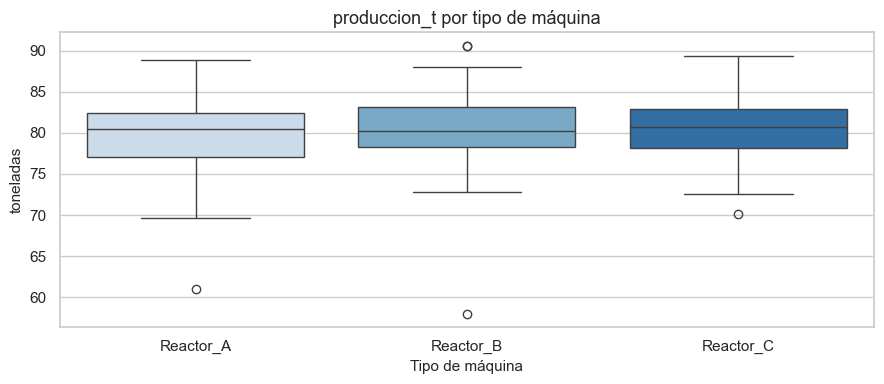

In [17]:
# Gráfico preparado para el análisis
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=df_sensor,
    x="tipo_maquina",
    y=VARIABLE_RETO,
    hue="tipo_maquina",
    palette="Blues",
    legend=False,
)
plt.title(f"{VARIABLE_RETO} por tipo de máquina")
plt.xlabel("Tipo de máquina")
plt.ylabel(UNIDAD_RETO)
plt.tight_layout()
plt.show()


#### Respuesta guiada del participante

Complete las frases. No se evalúa la sintaxis de Python; se evalúa la lectura
de la evidencia y la justificación de la decisión.

Hallazgo: la mediana de produccion_t es aproximadamente 80,52 toneladas y el IQR es 4,98 toneladas.
Calidad: se encontraron 2 valores faltantes y 6 candidatos según IQR.
Lectura del gráfico: el grupo con mayor dispersión es Reactor A y el de menor dispersión es Reactor C, considerando el tamaño de las cajas y el IQR.
Interpretación: este resultado podría indicar diferencias operativas, variabilidad del proceso o mediciones inusuales, aunque todavía no permite afirmar que el tipo de reactor sea la causa.
Decisión sugerida: recomiendo revisar los valores faltantes y los seis candidatos antes de imputar o eliminar, porque se necesita conocer el contexto operativo y conservar la trazabilidad.


In [18]:
# Comprobación del mini-reto
pd.testing.assert_frame_equal(df_sensor, df_raw_snapshot)
assert "faltante_reto" in df_reto.columns
assert "candidato_iqr_reto" in df_reto.columns
assert len(df_reto) == len(df_sensor)
assert int(df_reto["faltante_reto"].sum()) == int(serie_reto.isna().sum())

print("✓ El dataset original permanece intacto.")
print("✓ Los candidatos IQR fueron marcados, no eliminados.")
print("✓ El mini-reto está listo para documentar en Markdown.")


✓ El dataset original permanece intacto.
✓ Los candidatos IQR fueron marcados, no eliminados.
✓ El mini-reto está listo para documentar en Markdown.


#### Extensión opcional

Si terminó la parte obligatoria, cambie únicamente estas dos líneas y vuelva a
ejecutar las celdas del mini-reto:

```python
VARIABLE_RETO = "vibracion_mm_s"
UNIDAD_RETO = "mm/s"
```

Compare si la interpretación cambia cuando se analiza otra variable del proceso.
No es necesario modificar el resto del código.


---
## Entregable y trabajo autónomo (5 horas)

- **Lectura guiada (1 h):** EDA, visualización y dimensiones de calidad.
- **Notebook 3 (1 h):** ejecutar las celdas, completar el mini-reto guiado y documentar las interpretaciones.
- **Dataset del Proyecto (2 h):** aplicar estadísticas y tres gráficos exploratorios al dataset del Proyecto Integrador.
- **Ficha de calidad (0,5 h):** registrar problemas de calidad, códigos centinela y reglas propuestas.
- **Hito grupal (0,5 h):** revisión y carga en Classroom.

### Lista de verificación de la Ficha Exploratoria

- problema industrial y decisión que se busca mejorar;
- tabla de estadísticas descriptivas de variables críticas;
- tres gráficos interpretados desde el proceso, con títulos y unidades;
- problemas de calidad, códigos centinela y supuestos documentados;
- enlace de solo lectura al notebook reproducible;
- respuestas del mini-reto con hallazgo, interpretación y decisión sugerida;
- anonimización de personas y protección de información sensible.

**Siguiente sesión:** transformaciones reproducibles y vectorización con Pandas/NumPy.
